In [ ]:
# NE SLUZI NICEMU
import os
import shutil
import random

source_folder = "balanced_chosen_50_images"
target_folder = "balanced_chosen_10_images"
target_count = 5000

os.makedirs(target_folder, exist_ok=True)

for class_name in top_10:
    src_dir = os.path.join(source_folder, class_name)
    dst_dir = os.path.join(target_folder, class_name)
    os.makedirs(dst_dir, exist_ok=True)

    if os.path.exists(src_dir):
        all_images = [f for f in os.listdir(src_dir) if f.endswith(".png") or f.endswith(".jpg")]
        print(f"{class_name}: pronađeno {len(all_images)} slika")

        if len(all_images) > target_count:
            selected_images = random.sample(all_images, target_count)
        else:
            selected_images = all_images

        for img_name in selected_images:
            shutil.copy(
                os.path.join(src_dir, img_name),
                os.path.join(dst_dir, img_name)
            )

        print(f"Kopirano: {len(selected_images)} slika iz klase '{class_name}'")
    else:
        print(f"Nedostaje folder: {class_name}")


In [1]:
top_10 = ["snowman", "potato", "calendar", "marker", "banana", "hand", "diving board", "harp", "yoga", "cooler"]

In [ ]:
# NE SLUZI NICEMU
from PIL import ImageOps
import os
import shutil
import random
import cv2
import numpy as np

source_folder = "balanced_chosen_10_images"
target_folder = "balanced_chosen_10_images_preprocessed0"
#target_count = 5000

os.makedirs(target_folder, exist_ok=True)

for class_name in top_10:
    src_dir = os.path.join(source_folder, class_name)
    dst_dir = os.path.join(target_folder, class_name)
    os.makedirs(dst_dir, exist_ok=True)

    if os.path.exists(src_dir):
        all_images = [f for f in os.listdir(src_dir) if f.endswith(".png") or f.endswith(".jpg")]
        print(f"{class_name}: pronađeno {len(all_images)} slika")

        img = Image.open(src_dir).convert("L")
        img = img.convert("RGB")

        img = ImageOps.invert(img)
        
        img_np = np.array(img.convert("L"))
        kernel = np.ones((3,3), np.uint8)
        dilated = cv2.dilate(img_np, kernel, iterations=1)
        img = Image.fromarray(dilated).convert("RGB")

        

        '''

        if len(all_images) > target_count:
            selected_images = random.sample(all_images, target_count)
        else:
            selected_images = all_images

        for img_name in selected_images:
            shutil.copy(
                os.path.join(src_dir, img_name),
                os.path.join(dst_dir, img_name)
            )

        print(f"Kopirano: {len(selected_images)} slika iz klase '{class_name}'")
    else:
        print(f"Nedostaje folder: {class_name}")
        '''


In [ ]:
# NE SLUZI NICEMU
img = Image.open(path).convert("L")  # grayscale
img = img.convert("RGB")  # sada je 3-kanalna RGB slika sa istim vrednostima u sva 3 kanala

In [ ]:
# NE SLUZI NICEMU
from PIL import ImageOps
img = ImageOps.invert(img)


In [ ]:
# NE SLUZI NICEMU
import cv2
import numpy as np

img_np = np.array(img.convert("L"))
kernel = np.ones((3,3), np.uint8)
dilated = cv2.dilate(img_np, kernel, iterations=1)
img = Image.fromarray(dilated).convert("RGB")


In [ ]:
# NE SLUZI NICEMU
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [4]:
import os
src_dir1 = "balanced_chosen_10_images"
src1 = os.path.join("balanced_chosen_10_images", "banana", "banana_2794.png")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


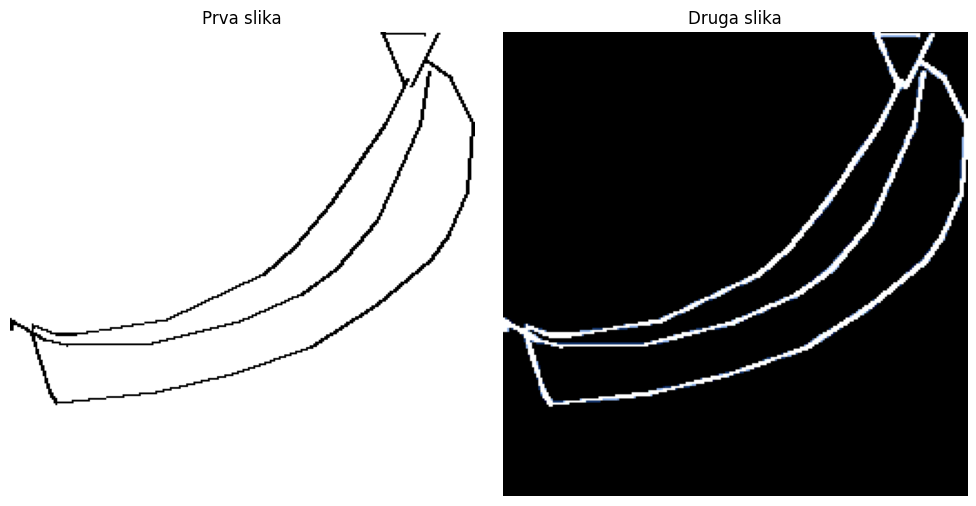

In [11]:
import matplotlib.pyplot as plt
from PIL import ImageOps
import numpy as np
import cv2
from PIL import Image



img1 = Image.open(src1).convert("L")
img = Image.open(src1).convert("L")
img = img.convert("RGB")

img = ImageOps.invert(img)
        
img_np = np.array(img.convert("L"))
kernel = np.ones((2,2), np.uint8)
dilated = cv2.dilate(img_np, kernel, iterations=1)
img = Image.fromarray(dilated).convert("RGB")

from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img = preprocess(img)

img_to_display = img.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Prikaz prve slike
axes[0].imshow(img1, cmap = "gray")
axes[0].set_title("Prva slika")
axes[0].axis("off")

# Prikaz druge slike
axes[1].imshow(img_to_display)
axes[1].set_title("Druga slika")
axes[1].axis("off")

plt.tight_layout()
plt.show()

banana: pronađeno 5000 slika


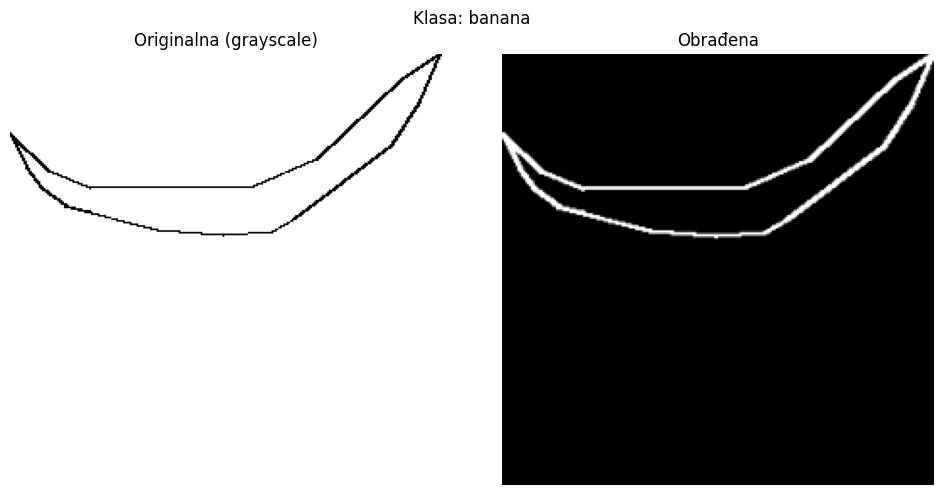

calendar: pronađeno 5000 slika


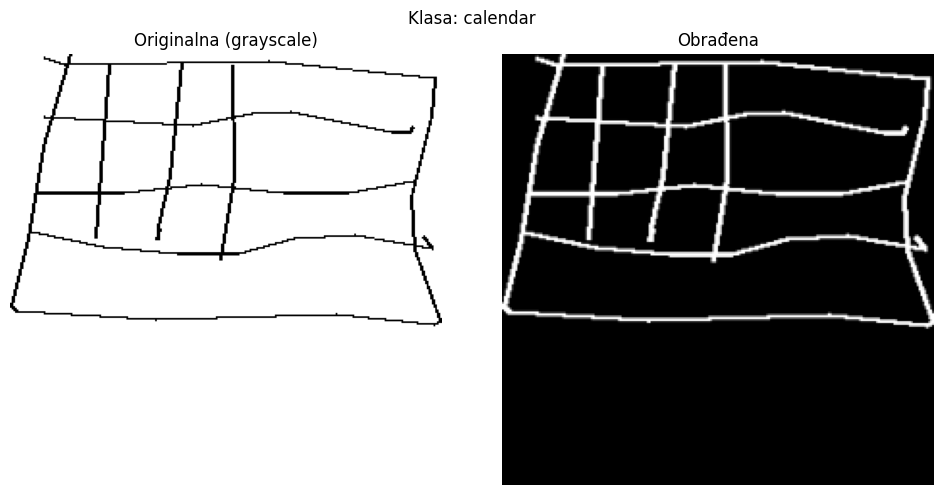

cooler: pronađeno 5000 slika


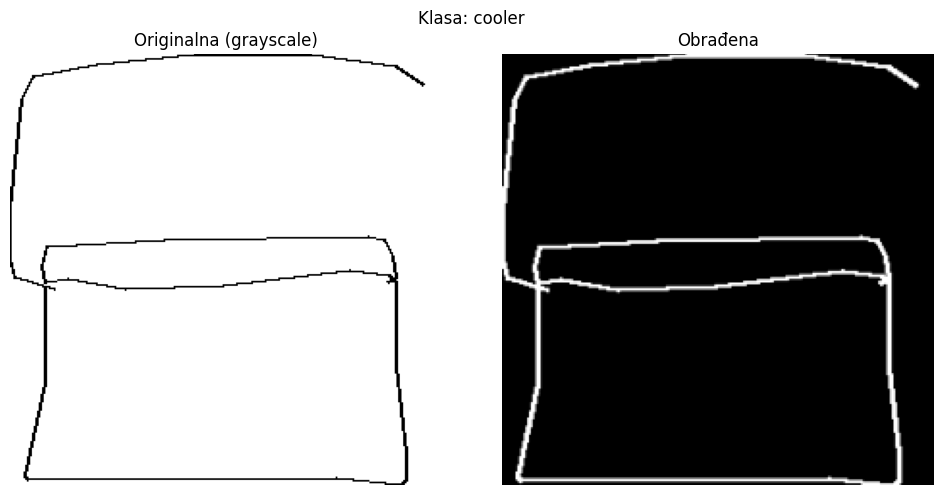

diving board: pronađeno 5000 slika


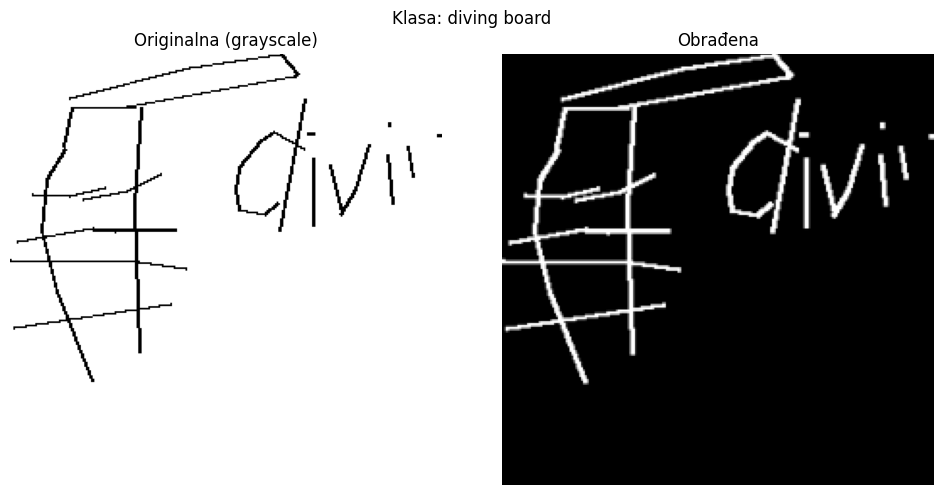

hand: pronađeno 5000 slika


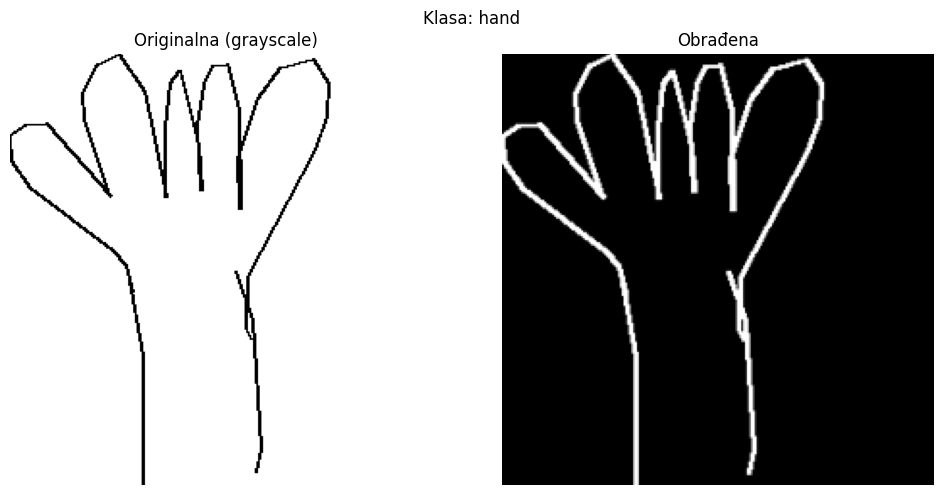

harp: pronađeno 5000 slika


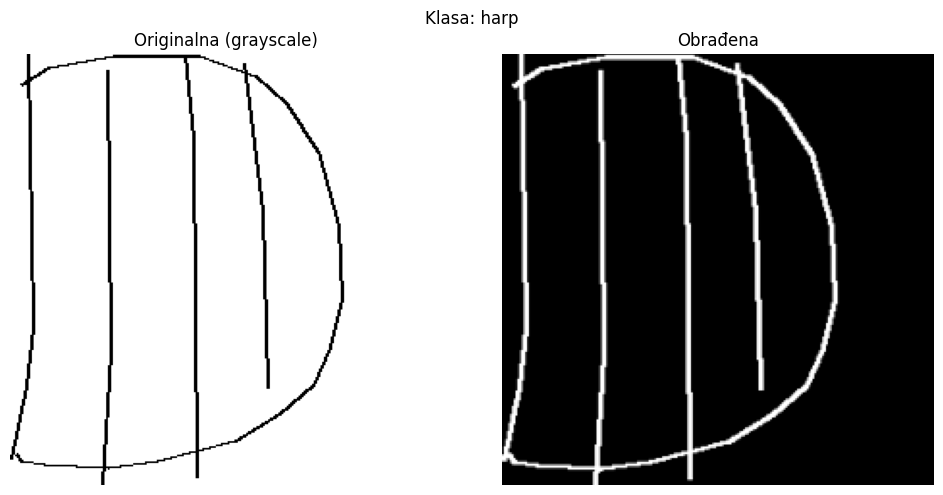

marker: pronađeno 5000 slika


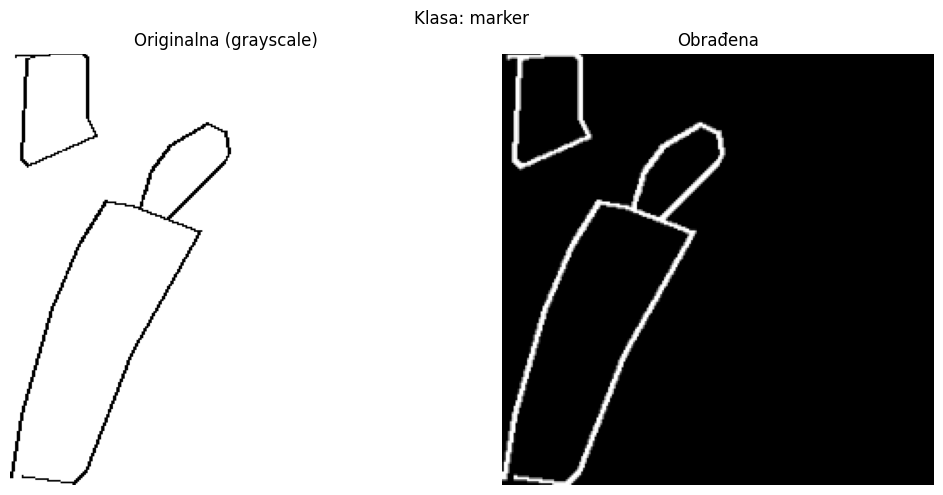

potato: pronađeno 5000 slika


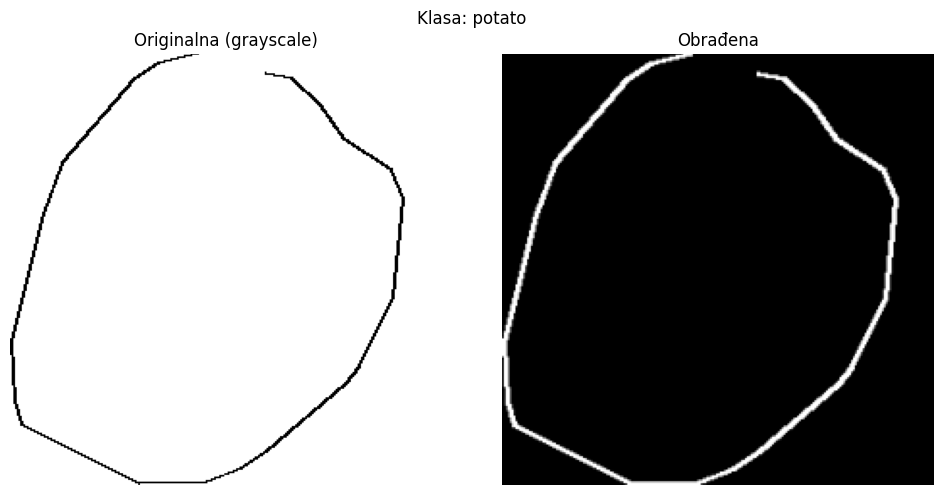

snowman: pronađeno 5000 slika


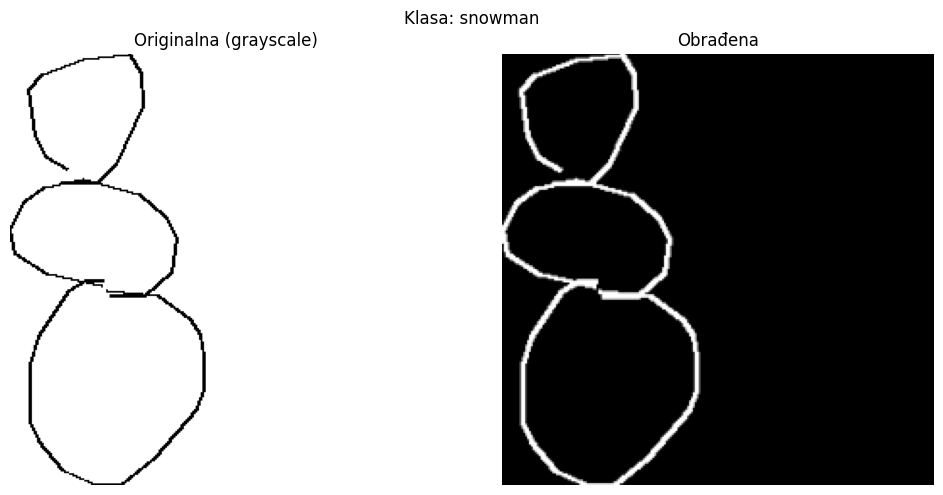

yoga: pronađeno 5000 slika


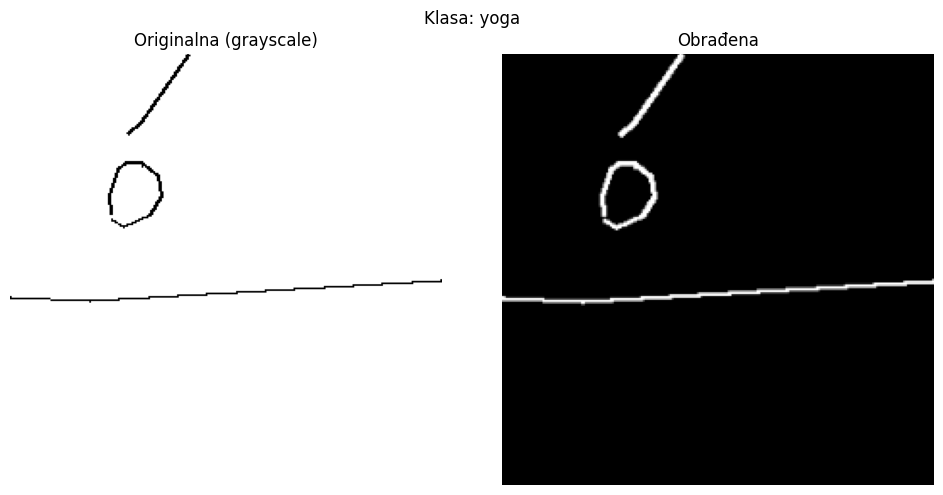

In [12]:
import os
import cv2
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from torchvision import transforms

# Parametri
source_folder = "balanced_chosen_10_images"
target_folder = "balanced_chosen_10_images_preprocessed0"
top_10 = os.listdir(source_folder)  # ili neka lista klasa ako već postoji

os.makedirs(target_folder, exist_ok=True)

# Transformacija za VGG16
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # (1,H,W) za grayscale ili (3,H,W) za RGB
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # VGG očekuje 3 kanala
        std=[0.229, 0.224, 0.225]
    )
])

# Prolazak kroz klase
for class_name in top_10:
    src_dir = os.path.join(source_folder, class_name)
    dst_dir = os.path.join(target_folder, class_name)
    os.makedirs(dst_dir, exist_ok=True)

    if not os.path.exists(src_dir):
        print(f"Nedostaje folder: {class_name}")
        continue

    all_images = [f for f in os.listdir(src_dir) if f.endswith(".png") or f.endswith(".jpg")]
    print(f"{class_name}: pronađeno {len(all_images)} slika")

    for i, img_name in enumerate(all_images):
        src_path = os.path.join(src_dir, img_name)
        dst_path = os.path.join(dst_dir, img_name)

        try:
            # Učitavanje kao grayscale
            img_orig = Image.open(src_path).convert("L")

            # Inverzija
            img_inv = ImageOps.invert(img_orig)

            # Dilacija linija
            img_np = np.array(img_inv)
            kernel = np.ones((2, 2), np.uint8)
            dilated = cv2.dilate(img_np, kernel, iterations=1)

            # Konverzija nazad u Image
            img_pil = Image.fromarray(dilated).convert("RGB")

            # Resize i normalizacija
            img_tensor = preprocess(img_pil)

            # Ako želiš da sačuvaš kao sliku (bez tenzorske normalizacije)
            # moraš da sačuvaš `dilated` ili resizeovani `img_pil`
            resized_img = img_pil.resize((224, 224))
            resized_img.save(dst_path)

            # (Opcionalno) Prikaz prve slike u svakoj klasi
            if i == 0:
                fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                axes[0].imshow(img_orig, cmap="gray")
                axes[0].set_title("Originalna (grayscale)")
                axes[0].axis("off")

                axes[1].imshow(resized_img.convert("L"), cmap="gray")
                axes[1].set_title("Obrađena")
                axes[1].axis("off")

                plt.suptitle(f"Klasa: {class_name}")
                plt.tight_layout()
                plt.show()

        except Exception as e:
            print(f"Greška pri obradi slike {img_name}: {e}")


In [1]:
import numpy as np
import cv2
from PIL import Image, ImageOps
import torchvision.transforms as transforms

class PreprocessingTransform:
    def __call__(self, img):
        # Invertuj sliku
        img = img.convert("RGB")
        img_inv = ImageOps.invert(img)

        # Dilacija
        img_np = np.array(img_inv)
        kernel = np.ones((2, 2), np.uint8)
        dilated = cv2.dilate(img_np, kernel, iterations=1)

        # Nazad u PIL format kao RGB
        img_pil = Image.fromarray(dilated).convert("RGB")
        return img_pil

In [2]:
preprocess = transforms.Compose([
    PreprocessingTransform(),                    # tvoj deo
    transforms.Resize((224, 224)),               # resize za VGG
    transforms.ToTensor(),                       # u tensor
    transforms.Normalize(                        # normalizacija za VGG
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    img_inv = ImageOps.invert(img_orig),

            # Dilacija linija
            img_np = np.array(img_inv)
            kernel = np.ones((2, 2), np.uint8)
            dilated = cv2.dilate(img_np, kernel, iterations=1)

            # Konverzija nazad u Image
            img_pil = Image.fromarray(dilated).convert("RGB")
    transforms.ToTensor(),  # (1,H,W) za grayscale ili (3,H,W) za RGB
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # VGG očekuje 3 kanala
        std=[0.229, 0.224, 0.225]
    )
])

img_orig = Image.open(src_path).convert("L")

            # Inverzija
            img_inv = ImageOps.invert(img_orig)

            # Dilacija linija
            img_np = np.array(img_inv)
            kernel = np.ones((2, 2), np.uint8)
            dilated = cv2.dilate(img_np, kernel, iterations=1)

            # Konverzija nazad u Image
            img_pil = Image.fromarray(dilated).convert("RGB")

            # Resize i normalizacija
            img_tensor = preprocess(img_pil)

            # Ako želiš da sačuvaš kao sliku (bez tenzorske normalizacije)
            # moraš da sačuvaš `dilated` ili resizeovani `img_pil`
            resized_img = img_pil.resize((224, 224))
            resized_img.save(dst_path)

In [14]:
import os
import shutil
import random

top_3 = ["snowman", "potato", "calendar"]

source_folder = "balanced_chosen_10_images_preprocessed0"
target_folder = "balanced_chosen_3_images_preprocessed0"
target_count = 1000

os.makedirs(target_folder, exist_ok=True)

for class_name in top_3:
    src_dir = os.path.join(source_folder, class_name)
    dst_dir = os.path.join(target_folder, class_name)
    os.makedirs(dst_dir, exist_ok=True)

    if os.path.exists(src_dir):
        all_images = [f for f in os.listdir(src_dir) if f.endswith(".png") or f.endswith(".jpg")]
        print(f"{class_name}: pronađeno {len(all_images)} slika")

        if len(all_images) > target_count:
            selected_images = random.sample(all_images, target_count)
        else:
            selected_images = all_images

        for img_name in selected_images:
            shutil.copy(
                os.path.join(src_dir, img_name),
                os.path.join(dst_dir, img_name)
            )

        print(f"Kopirano: {len(selected_images)} slika iz klase '{class_name}'")
    else:
        print(f"Nedostaje folder: {class_name}")

snowman: pronađeno 5000 slika
Kopirano: 1000 slika iz klase 'snowman'
potato: pronađeno 5000 slika
Kopirano: 1000 slika iz klase 'potato'
calendar: pronađeno 5000 slika
Kopirano: 1000 slika iz klase 'calendar'


In [ ]:
import os
import shutil
import random

top_3 = ["snowman", "potato", "calendar"]

source_folder = "balanced_chosen_10_images"
target_folder = "balanced_chosen_3_images"
target_count = 1000

os.makedirs(target_folder, exist_ok=True)

for class_name in top_3:
    src_dir = os.path.join(source_folder, class_name)
    dst_dir = os.path.join(target_folder, class_name)
    os.makedirs(dst_dir, exist_ok=True)

    if os.path.exists(src_dir):
        all_images = [f for f in os.listdir(src_dir) if f.endswith(".png") or f.endswith(".jpg")]
        print(f"{class_name}: pronađeno {len(all_images)} slika")

        if len(all_images) > target_count:
            selected_images = random.sample(all_images, target_count)
        else:
            selected_images = all_images

        for img_name in selected_images:
            shutil.copy(
                os.path.join(src_dir, img_name),
                os.path.join(dst_dir, img_name)
            )

        print(f"Kopirano: {len(selected_images)} slika iz klase '{class_name}'")
    else:
        print(f"Nedostaje folder: {class_name}")

snowman: pronađeno 5000 slika
Kopirano: 1000 slika iz klase 'snowman'
potato: pronađeno 5000 slika
Kopirano: 1000 slika iz klase 'potato'
calendar: pronađeno 5000 slika
Kopirano: 1000 slika iz klase 'calendar'


: 